# Z-score 归一化
- 通常应用在优势函数（Advantage）的计算阶段，这是稳定训练最关键的一步。

## 核心逻辑说明
- 计算原始优势：使用 GAE（广义优势估计）算法计算每个 token 的原始优势值。
- Batch 级归一化：在每个 mini-batch 更新前，计算当前 batch 内优势值的均值和标准差。
- 执行标准化：套用公式 $A_{norm} = \frac{A - μ}{σ + ϵ }$
- 安全保护：加入 ϵ （如 1e-8）防止除以零；

<font color='red'>如果标准差过小（说明所有优势都差不多），则不进行缩放，仅做中心化或保持原样</font>

## Python 代码实现

 

In [ ]:
import torch
import torch.nn.functional as F

class PPOTrainerWithZScore:
    def __init__(self, config):
        self.gamma = config.get("gamma", 0.99)
        self.gae_lambda = config.get("gae_lambda", 0.95)
        self.clip_epsilon = config.get("clip_epsilon", 0.2)
        # 防止除以0的安全项
        self.eps = 1e-8 

    def compute_gae(self, rewards, values, masks):
        """
        计算广义优势估计 (GAE)
        这是归一化的前置步骤
        """
        advantages = []
        gae = 0.0
        next_value = 0.0 
        
        # 倒序遍历计算 GAE
        for t in reversed(range(len(rewards))):
            if masks[t]:
                delta = rewards[t] + self.gamma * next_value - values[t]
                gae = delta + self.gamma * self.gae_lambda * gae
                advantages.insert(0, gae)
            else:
                gae = 0.0
                advantages.insert(0, 0.0)
            next_value = values[t]
            
        return torch.tensor(advantages, dtype=torch.float32)

    def normalize_advantages(self, advantages):
        """
        【核心功能】Z-score 归一化优势函数
        """
        # 1. 计算当前 batch 的均值和标准差
        adv_mean = advantages.mean()
        adv_std = advantages.std(unbiased=False) # unbiased=False 对应 population std
        
        # 2. 执行 Z-score 公式
        # 注意：加上 self.eps 防止 std 为 0 时导致 NaN
        normalized_advantages = (advantages - adv_mean) / (adv_std + self.eps)
        
        return normalized_advantages

    def ppo_update_step(self, old_log_probs, new_log_probs, raw_advantages):
        """
        模拟一次 PPO 的参数更新步骤
        """
        # --- 步骤 A: Z-score 归一化 ---
        # 在送入 Loss 计算之前，先处理优势值
        norm_advantages = self.normalize_advantages(raw_advantages)
        
        # --- 步骤 B: 计算 Ratio ---
        ratio = torch.exp(new_log_probs - old_log_probs)
        
        # --- 步骤 C: 计算 Clipped Loss ---
        surr1 = ratio * norm_advantages
        surr2 = torch.clamp(ratio, 1.0 - self.clip_epsilon, 1.0 + self.clip_epsilon) * norm_advantages
        
        # PPO 目标是最大化收益，所以取负号作为 Loss
        loss = -torch.min(surr1, surr2).mean()
        
        return loss, norm_advantages

# ==========================================
# 模拟训练循环演示
# ==========================================
if __name__ == "__main__":
    # 假设配置
    config = {"gamma": 0.99, "gae_lambda": 0.95}
    trainer = PPOTrainerWithZScore(config)
    
    # 模拟一个 Batch 的数据 (Batch Size = 4, Sequence Length = 5)
    # 这里为了演示简单，把 Sequence 展平了，实际中通常是 (Batch, Seq_Len)
    batch_size = 32
    
    # 模拟原始优势值：假设模型表现波动很大，有的很好(10)，有的很差(-5)
    raw_adv_batch = torch.randn(batch_size) * 5 + 2 
    
    print(f"归一化前 - 均值: {raw_adv_batch.mean():.4f}, 标准差: {raw_adv_batch.std():.4f}")
    print(f"归一化前 - 最大值: {raw_adv_batch.max():.4f}, 最小值: {raw_adv_batch.min():.4f}")
    
    # 执行归一化
    norm_adv_batch = trainer.normalize_advantages(raw_adv_batch)
    
    print("-" * 30)
    
    print(f"归一化后 - 均值: {norm_adv_batch.mean():.4f} (接近 0)")
    print(f"归一化后 - 标准差: {norm_adv_batch.std():.4f} (接近 1)")
    print(f"归一化后 - 最大值: {norm_adv_batch.max():.4f}")
    print(f"归一化后 - 最小值: {norm_adv_batch.min():.4f}")

### 代码关键点解析
1. unbiased=False
  - 在计算标准差时，建议使用 unbiased=False（即<font color='red'>除以 N 而不是 N−1</font> ）。
    - <font color='red'>这是因为我们是在对当前的 Mini-batch 进行标准化，将其视为一个整体分布，而不是去估算整个数据集的分布。这在深度学习框架（如 PyTorch 的 BatchNorm）中是惯例</font>

2. eps 的作用
  - 代码中的 self.eps = 1e-8 至关重要。
    - 如果在一个 Batch 中，所有样本的优势值都一样（例如都是 0），那么标准差 σ 就是 0。如果没有这个 eps，代码就会报错 Division by zero 或产生 NaN。

3. 作用范围
  - 注意：<font color='red'>Z-score 归一化通常是基于当前 Mini-batch 进行的，而不是基于整个数据集的历史统计量</font>（不像推理时的 BatchNorm）。因为 RL 的数据分布是**非平稳的**（Non-stationary），策略在不断变化，奖励的基准线也在变，所以必须用当前批次的数据来动态调整。

### 预期输出结果
运行上述代码，你会看到类似下面的输出，证明归一化生效了：

In [ ]:
归一化前 - 均值: 2.1534, 标准差: 4.8921
归一化前 - 最大值: 13.5672, 最小值: -8.2341
        
------------------------------

归一化后 - 均值:    -0.0000 (接近 0)
归一化后 - 标准差:   1.0000 (接近 1)
归一化后 - 最大值:   2.3211
归一化后 - 最小值:  -2.1105

<font color='red'>这表明无论原始奖励多么剧烈波动，经过处理后，它们都被拉回到了一个模型容易学习的“舒适区”</font>

# unbiased=False
- 是 PyTorch 中 torch.std() 和 torch.var() 等统计函数的一个参数，<font color='red'>它控制计算方差/标准差时分母的选择，直接决定了你得到的是"**总体标准差**"还是"**样本标准差**"。</font>

## 两种计算方式的区别

In [1]:
from IPython.display import Image

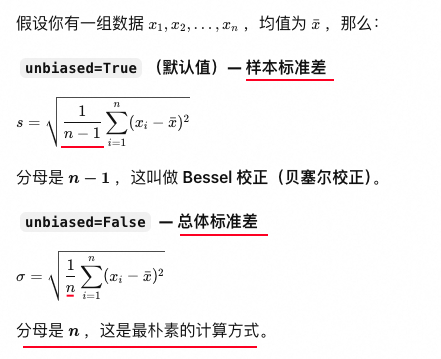

In [2]:
Image(filename='./Image/unbiased.png')

## 为什么会有两种？—— "无偏估计"的统计学含义
关键在于：<font color='red'>你用这组数据来估计什么？</font>

### 场景 A：你<font color='blue'>拥有"全部数据"（总体）</font>-- <font color='red'>用n</font>
  - 如果你手里就是全部数据（比如全班 50 人的考试成绩），那你直接<font color='red'>用 n </font>做分母就行。这就是 unbiased=False。
  
### 场景 B：你<font color='blue'>只有"一部分数据"（样本）</font>，想推断整体 -- <font color='red'>用n-1</font>
  - <font color='blue'>如果你只抽了 50 人，想推断全校 5000 人的方差，那么用 n 做分母会系统性地低估真实方差。</font>
    - 原因是：<font color='red'>样本均值 xˉ本身是从这 n 个数据算出来的，它天然比总体均值 μ 更"靠近"这 n 个数据点，导致 $∑(x_i − xˉ)^2$偏小</font>
  
  - <font color='blue'>为了纠正这个偏差，统计学家把分母从 n 改为 n−1 </font>。这样在大量重复抽样下，估计值的期望恰好等于真实方差，即 $E(s^2)=σ^2$，这就是无偏估计的含义。
    - 简单说：
      - unbiased=True 是为了"用样本猜总体"时更准确；
      - unbiased=False 是"就事论事"地描述当前这组数据本身。
    
## 数值差异有多大？
以 PyTorch 官方示例为例：

In [3]:
import torch
x = torch.tensor([1.0, 2.0, 3.0])

# unbiased=True（分母 n-1 = 2）
torch.std(x)                    # 输出：1.0

# unbiased=False（分母 n = 3）
torch.std(x, unbiased=False)    # 输出：0.8165（即 √(2/3)）

tensor(0.8165)

可以看到，当 n=3 时差异很明显。但随着 n 增大，两者的差距会迅速缩小：

| 样本量  $ n $  | 差异比例 |
|:---:|:---:|
| 3 | ~18% |
| 10 | ~5% |
| 32（典型 batch size） | ~1.6% |
| 1000 | ~0.05% |

<font color='red'>当 n 很大时， n 和 n−1 几乎没有区别</font>。

## 在 PPO 训练中为什么用 unbiased=False？ -- 用n
回到之前 PPO 代码中的这行：

In [ ]:
adv_std = advantages.std(unbiased=False)

**选择 unbiased=False 的原因是：**
  - 我们不是在做统计推断。我们不需要用这个 batch 的优势值去"猜测"整个训练过程的方差。<font color='red'>我们只是想描述当前这批数据的离散程度，然后把它标准化</font>
  - ***Batch size 通常足够大（如 32、64、128），此时 n 和 n−1 的差异可以忽略不计***。
  - 语义更清晰。我们在做的是"把这个 batch 的数据缩放到均值为 0、标准差为 1"，这是一个确定性的数据变换操作，不是统计估计。
    - 实际上，PyTorch 的 BatchNorm 层在训练时也使用类似的逻辑
      - <font color='red'>对当前 batch 计算均值和方差时，分母用的是 n （即 unbiased=False 的思路），而不是 n−1</font> 。
    
## 一句话总结

| 参数 | 分母 | 适用场景 |
|:---|:---:|:---|
| `unbiased=True` |   n-1   | 用样本推断总体方差（统计学场景） |
| `unbiased=False` |   n  | 描述当前数据本身的离散程度（深度学习归一化场景） |


在深度学习中，绝大多数归一化操作（BatchNorm、LayerNorm、Advantage Normalization）都用 unbiased=False，因为我们关注的是当前这批数据的标准化，而不是用样本去估计总体参数。